<a href="https://colab.research.google.com/github/TejasDharmale/Bayesian-machine-learning-assignment/blob/main/A2BNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bayesian Machine Learning
##  Assignment 2: **Bayesian Neural Networks in Jax**

    Name: Tejas Dharmale
    Student #: s1190137

In the first lecture of this course, we considered neural networks through a statistical lens as a non-linear regression model, with weights we want to infer for a given set of observations. In this assignment, we consider the ability of a *Bayesian* neural network to give meaningful predictions of uncertainty. This notebook consists of three parts:

- *Part I*: Implementing a MLP in Jax (10/3 points)
- *Part II*: Ensemble models (10/3 points)
- *Part III*: Bayesian MLPs with MCMC (10/3 points)

The goal of this assignment is to obtain a deeper understanding of Bayesian neural networks, inference techniques, and the effect of the prior distribution on the model predictions. Throughout the assignment, we consider the following synthetic dataset as a running example:

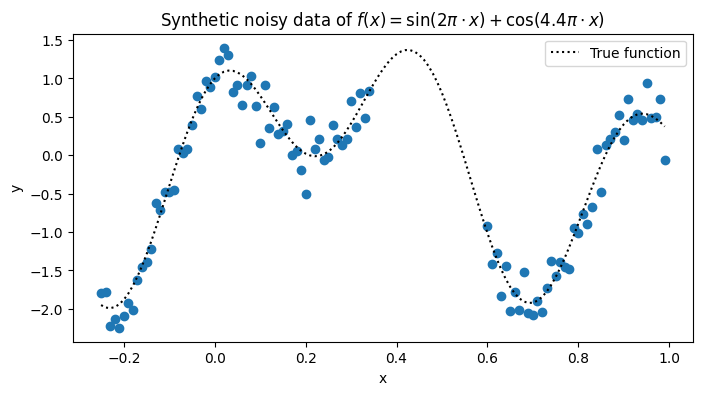

In [1]:
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.random as jr

def true_func(x):
    return jnp.sin(2*jnp.pi*x) + jnp.cos(4.4 * jnp.pi*x)

key = jr.PRNGKey(42)
step = 0.01
noise_std = 0.25
xs = jnp.concatenate((jnp.arange(-.25,0.35, step=step), jnp.arange(0.6, 1., step=step)))[:,None]

# sample noise observations
key, subkey = jr.split(key)
ys = true_func(xs) + jr.normal(key=subkey, shape=xs.shape)*noise_std

# true function that we cannot observe
dense_step = 0.01
xs_dense = jnp.arange(-.25, 1., dense_step)[:,None]
ys_dense = true_func(xs_dense)

# Visualization
fig, ax = plt.subplots(1,1,figsize=(8,4))
ax.plot(xs_dense, true_func(xs_dense), color='black', linestyle=':', label='True function')
ax.legend()
ax.scatter(xs, ys, label='Noisy observations')
ax.set_title(r'Synthetic noisy data of $f(x)=\sin(2\pi \cdot x ) + \cos (4.4\pi \cdot x) $')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

## Part I: **Implementing a MLP in Jax** (10/3 points)

### Ia. Implementing the network and the forward pass.
We start with creating a basic multi-layer perceptron (MLP) in Jax. Jax represents neural networks using 'PyTrees', which is a nested Python container (like lists, tuples, or dictionaries) containing JAX arrays. Here, we use an array containing a tuple of weights and biases for each layer: [$(w_1, b_1), \dots, (w_L, b_L)$].

Write a function that initializes such a PyTree with random values from a Gaussian distribution $w_i \sim \mathcal{N}(0,\sigma)$, with $\sigma =0.01$. You may consider the partially given 'initialize_mlp()' function as a starting point. Note that the input 'layer_sizes' are assumed to be a tuple corresponding to the number of units per layer, e.g. (1,16,8,1) denotes an MLP with a one-dimensional input, followed by a hidden layer of 16 neurons, another hidden layer of 8 neurons, and a final one-dimensional output.

Then, write a function 'network' that takes an input $x$ and the randomly initialized PyTree obtained from the previous function, to perform a forward pass of the network. You can do so by recursively computing for each layer $i \in [1, \dots, L]$:
\begin{align}
    f_i(x;\boldsymbol{w}_i) &= \tanh (\boldsymbol{w}_i x + b_i )
\end{align}
In the final layer, the activation function is not required.


In [3]:
def initialize_mlp(layer_sizes, key:jr.PRNGKey, scale:float=1e-2):
    """
    Inputs:
        layer_sizes (tuple) Tuple of shapes of the neural network layers.
                            Includes the input shape, hidden layer shape, and output layer shape: (input_dim, hidden_dim, ..., output_dim.)
        key (PRNGKey)
        scale (float) standard deviation of initial weights and biases

    Return:
        params (List) Tuple of weights and biases - [ (weights_1, biases_1), ..., (weights_n, biases_n) ]
    """
    params = []
    for in_dim, out_dim in zip(layer_sizes[:-1], layer_sizes[1:]):
        key, w_key, b_key = jr.split(key, 3)
        w = scale * jr.normal(w_key, (out_dim, in_dim))
        b = scale * jr.normal(b_key, (out_dim,))
        params.append((w, b))
    return params


def network(x, params):
    """ Standard MLP.

    Inputs:
        params (PyTree) Parameters of the policy network, represented as PyTree.
        x (D,) input state, where D is the dimensionality of the state observation.

    Returns:
        y_prediction (1,) One-dimensional array of predictions for the inputs x.
    """
    for w, b in params[:-1]:
        x = jnp.tanh(w @ x + b)

    w, b = params[-1]
    output = w @ x + b

    return output

In [5]:
layer_sizes = (1, 32, 32, 1)

key = jr.PRNGKey(42)
key, subkey = jr.split(key)
test_input = jnp.array([0.])
params = initialize_mlp(layer_sizes, subkey)
test_output = network(test_input, params)
print(test_output)

[0.01373114]


### Ib. Log likelihood objective function

A common optimization loss function is the mean squared error, defined as:
\begin{align}
    L_{\text{MSE}}(x) = \left( f(x;w)- y \right)^2 \qquad \text{(Single observation)},  \qquad  L_{\text{MSE}}(\boldsymbol{x}) = \frac{1}{N} \sum_{i=1}^N \left( f(x_i;w)- y_i \right)^2 \qquad \text{(Multiple observations)}
\end{align}
where $f$ is our neural network.
However, this does not account for any potential measurement errors in the data. We can add potential noise in the observations via the *likelihood* function, such as a Gaussian distribution for the errors:
\begin{align}
    p(y \mid x, w) &= \mathcal{N}(y \mid f(x; w), \sigma^2_{\text{Obs}})  \qquad \text{(Single observation)} ,\qquad  p(\boldsymbol{y} \mid \boldsymbol{x}, w) = \prod_{i=1}^{N} \mathcal{N}(y_i \mid f(x_i; w), \sigma^2_{\text{Obs}}) \qquad \text{(Multiple observations)}\\  
\end{align}

If we instead consider the negative *log* likelihood instead, this simplifies (🥳):
\begin{align}
    - \ln p(\boldsymbol{y} \mid \boldsymbol{x}, w) &= - \sum_{i=1}^{N} \ln \mathcal{N}(y \mid f(x; w), \sigma^2_{\text{Obs}})
    = - (\sum_{i=1}^{N} - \frac{1}{2} \ln (2\pi \sigma^2_{\text{Obs}}) -  \dfrac{(y_i - f(x_i; w))^2}{2 \sigma^2_{\text{Obs}}}) \propto \sum_{i=1}^{N} \dfrac{(y_i - f(x_i; w))^2}{2 \sigma^2_{\text{Obs}}}
\end{align}

Since the normalization term is the same constant term for all the weights, it does not influence the gradient. This expression now becomes **very similar** to the MSE objective, except that we now consider the measurement noise as well.

Write a function that implements the mean negative log likelihood objective (similar to the NLL objective, but now dividing with the number of datapoints $N$). You may assume the true measurement error size is known, and equals $\sigma_{\text{Obs}}=0.25$. To do so, create a helper function 'forward_pass', that receives not one input $x$ but an array of inputs $\boldsymbol{x} = [x_1, \dots, x_n]$, and performs a forward pass on each.

In [7]:
from jax.scipy.stats import multivariate_normal

def forward_pass(xs, params):
    """
    Arguments:
        xs (N,1) batched array of inputs.
        params (PyTree) A pytree corresponding to a single instantiation of our network.

    Return:
        predictions (N,1) batched array of predictions, computed by calling the 'network()' function using vmap.
    """
    return jax.vmap(network, in_axes=(0, None))(xs, params)


def mean_negative_log_likelihood(params, data):
    """
    Arguments:
        params (PyTree) A pytree corresponding to a single instantiation of our network.
        data (Tuple) Tuple consisting of (xs, ys), both of which have shape (N,1).

    Return:
        mean_negative_log_likelihood (float) The mean negative log likelihood comptued over the entire dataset.
    """
    xs, ys = data
    sigma_obs = 0.25 # We assume that we know the sensor noise.

    predictions = forward_pass(xs, params)

    return -jnp.mean(
        multivariate_normal.logpdf(
            ys, mean=predictions, cov=sigma_obs**2
        )
    )

Combine the functions above, by initializing your network, and evaluating it's (untrained) mean negative log likelihood (MNLL). This should result in a value for the MNLL score.

In [9]:
layer_sizes = (1, 32, 32, 1)

key = jr.PRNGKey(42)
key, subkey = jr.split(key)
params = initialize_mlp(layer_sizes, subkey)
data = (xs, ys)
mnll = mean_negative_log_likelihood(params, data)
print(mnll)

9.360125


Use the code below to optimize the parameters of your network using gradient descent algorithm with the Adam optimizer. The code is given to you ready-to-use, however it may be helpful to read thorugh it.

Choose a suitable number of iterations and learning rate, and optimize the MNLL on the data. Visualize the model fit on the data, as well as the true function.

- How well does the model fit the data?

- What is predicted in the interpolated region between $x=0.3$ and $x=0.6$?

In [11]:
import optax

def optimize_single_network(initial_params, learning_rate:float=0.005, num_iterations:int=7_000):
    """
        This function trains a neural network using gradient descent with Adam, on the dataset of (xs, ys).

    Arguments:
        initial_params (PyTree) initial
        learning_rate (float) learning_rate
        num_iterations (int) Number of gradient descent steps

    Returns:
        params (PyTree) optimized network parameters as PyTree.
        loss_vals (Array) evaluation scores for each iteration.
    """
    # initialize network
    params = initial_params
    data = (xs, ys)
    optim = optax.adam(learning_rate=learning_rate)
    state = optim.init(params)

    # Optimization
    loss_vals = jnp.zeros((num_iterations))
    jitted_likelihood = jax.jit(mean_negative_log_likelihood)

    for i in jnp.arange(num_iterations):
        loss_val, loss_gradient = jax.value_and_grad(jitted_likelihood)(params, data)
        updates, state = optim.update(loss_gradient, state, params)
        params = optax.apply_updates(params, updates)
        loss_vals = loss_vals.at[i].set(loss_val)

    return params, loss_vals

Initial MNLL: 9.360125
Final MNLL: -0.17609054


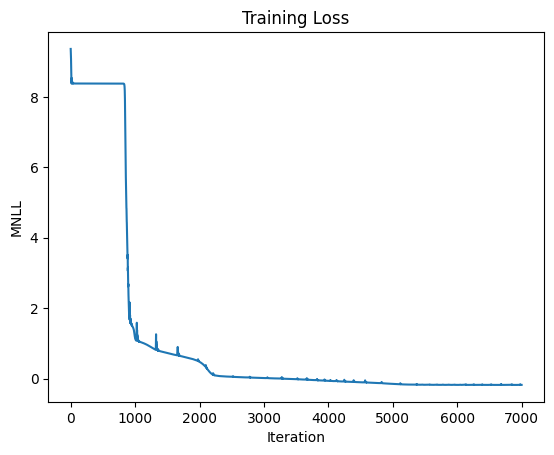

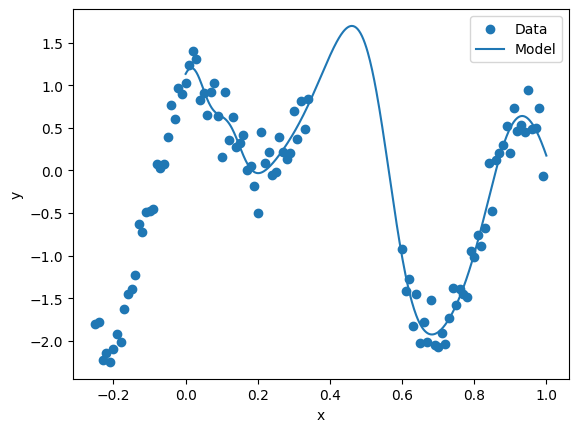

In [12]:
# Initialize network
layer_sizes = (1, 32, 32, 1)
key = jr.PRNGKey(42)
key, subkey = jr.split(key)

initial_params = initialize_mlp(layer_sizes, subkey)

# Train network
trained_params, loss_vals = optimize_single_network(
    initial_params,
    learning_rate=0.005,
    num_iterations=7000
)


print("Initial MNLL:", loss_vals[0])
print("Final MNLL:", loss_vals[-1])

# Plot
plt.plot(loss_vals)
plt.xlabel("Iteration")
plt.ylabel("MNLL")
plt.title("Training Loss")
plt.show()

# Model predictions
x_plot = jnp.linspace(0, 1, 500).reshape(-1, 1)
y_pred = forward_pass(x_plot, trained_params)


plt.scatter(xs, ys, label="Data")
plt.plot(x_plot, y_pred, label="Model")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## II. **Ensemble models** (10/3 points)

### IIa. Implementing ensemble MLPs (5/3 pts)
Ensemble models, as discussed in lecture 2, can provide a basic form of uncertainty quantification, albeit not directly founded on Bayesian principles. Create an ensemble of neural networks by repeating the previous exercise $m=20$ times with different random weight initializations. An efficient way to this, is to use the vmap function to create $m$ initial parameters using $m$ different keys, and use another vmap function on the 'optimize_single_network()'.

Visualize the model fits of all $m$ ensemble members on the data, as well as the true function. Then, compute the mean and standard deviation of the predictions across the ensemble members, and visualize these in your plot together with the samples.

How well do the $m$ models fit the data? What is predicted in the interpolated region between $x=0.3$ and $x=0.6$?

In [ ]:
## Your code here

Your answer here

### IIb. Optimizing the joint distribution: assigning a prior distribution to the neural network weights. (5/3 points)
Thus far, we have considered pure optimization of the weights. As a bridge to the inference algorithms such as Metropolis-Hastings or MALA, we can also consider an optimization approach that incorporates the prior distribution. One can do so by specifying a prior distribution over the weights, and optimizing the log joint distribution. If we were to consider full inference, the goal would be to identify the posterior distribution:
\begin{align}
    \overbrace{p(\boldsymbol{y} \mid \boldsymbol{x} )}^{\text{Posterior}} &= \dfrac{\overbrace{p(\boldsymbol{w})}^{\text{Prior}} \: \overbrace{p(\boldsymbol{y}\mid \boldsymbol{x}, \boldsymbol{w})}^{\text{Likelihood}}}{\underbrace{p(\mathcal{D})}_{\text{Evidence}}} \propto \overbrace{p(\boldsymbol{w}) p(\boldsymbol{y}\mid \boldsymbol{x}, \boldsymbol{w})}^{\text{Joint probability}}\\  
\end{align}
When we (once more) consider the log probability, we find that incorporating the prior distribution results in adding an additional prior probability to our original log likelihood:
\begin{align}
    \ln \left(p(\boldsymbol{w}) p(\boldsymbol{y}\mid \boldsymbol{x}, \boldsymbol{w}) \right) \propto \ln p(\boldsymbol{w}) + \ln p(\boldsymbol{y} \mid  \boldsymbol{x}, \boldsymbol{w})
\end{align}
By incorporating our prior beliefs over the weights, we insert our prior belief into the modeling procedure on how the true function behaves. A common prior is a diagonal Gaussian distribution:
\begin{align}
    p(\boldsymbol{w}) = \mathcal{N}(\boldsymbol{0}, \boldsymbol{I} \cdot s )
\end{align}
where s is a scale term.


a. Explain how the influence of the prior distribution on the posterior changes as we observe more data points. (1/3 pts)

your answer here

b. Write analytically how you can conveniently compute $\ln p(\boldsymbol{w})$. (1/3 pts)

your answer here

c. Repeat the previous exercise of training an ensemble model with the mean log joint probability as an objective. For the prior, start with an isotropic Gaussian with large scale parameter of $s=5$. Since we computed the mean over datapoints for the NLL to obtain the mean MNLL, we will also have to divide the log prior term by N to match the scaling. Lastyl, think carefully whether you need to *maximize* or *minimize*. (1/3 pts)

Demonstrate and explain what the effect your prior distribution is, by comparing it to the model fit under the log likelihood objective.

In [ ]:
# Your code here

your answer here

d. Argue if an ensemble of neural network models, each trained to optimize the log joint probability, can be considered as a "Bayesian" model. (1/3 pts)


Your answer here

e. What happens to the predictions of the ensemble when the scale $s$ shrinks or grows? Show this numerically and explain your observations. (1/3 pts)


In [ ]:
## your code here

yoru answer here

## III. **Bayesian MLPs with Markov Chain Monte Carlo** (10/3 points)

Building on previous week's assignment, we will again estimate a density, however this week the density is a bit more than the banana function: it is the posterior density of a Bayesian neural network!
Use your Metropolis-Hastings implementation from last week, together with the Gaussian proposal distribution. As the target density, we will use the log joint distribution from the previous exericse, using the same prior. If you do not have a working solution for Metropolis-Hastings, please reach out to the TAs.

After obtaining a good step size and an appropriate number of burn in steps and total iterations, compare the predictive posterior distribution to the ensemble models in the previous exercise. Again, consider various prior scales $s$. Explain your observations, in particular the uncertainty on the observations and on the interpolated region, and argue what uncertainty is appropriate given the data points that are observed.

**Implementational note:** To implement this, note that a 'flat' array representation of the weights is used rather than a PyTree. The following function will give you this: "flattened_params, reverse_function = jax.flatten_util.ravel_pytree(params)". Here 'flattened_params' is an Array of all the weights and biases. Calling 'reverse_function(flatten_params)" will give you back the original PyTree structure.

**Fun exercise** (no bonus points): If you like, you are welcome to experiment with the MALA algorithm. However, take into account that the MALA algorithm can be very senstive to the step size, making it challenging to obtain a good out-of-the-box estimate.


In [ ]:
## your code here
# example use of 'flattening' an array:
example_layer_sizes = (2,3,1)
example_params = initialize_mlp(layer_sizes=example_layer_sizes, key=subkey)
print('PyTree parameters: ', example_params)
example_flattened_params, example_reverse_function = jax.flatten_util.ravel_pytree(example_params)
print('\nParameters in an array: ', example_flattened_params)
print('\nRecovered Pytree parameters: ' ,example_reverse_function(example_flattened_params))

PyTree parameters:  [(Array([[-0.07387265,  0.02851088],
       [-0.03561139,  0.09743211],
       [ 0.03176116,  0.04705815]], dtype=float32), Array([ 0.09008338,  0.11630451, -0.04864509], dtype=float32)), (Array([[ 0.09008338,  0.11630451, -0.04864509]], dtype=float32), Array([-0.0858328], dtype=float32))]

Parameters in an array:  [-0.07387265  0.02851088 -0.03561139  0.09743211  0.03176116  0.04705815
  0.09008338  0.11630451 -0.04864509  0.09008338  0.11630451 -0.04864509
 -0.0858328 ]

Recovered Pytree parameters:  [(Array([[-0.07387265,  0.02851088],
       [-0.03561139,  0.09743211],
       [ 0.03176116,  0.04705815]], dtype=float32), Array([ 0.09008338,  0.11630451, -0.04864509], dtype=float32)), (Array([[ 0.09008338,  0.11630451, -0.04864509]], dtype=float32), Array([-0.0858328], dtype=float32))]


Your answer here